# B-cell RNA velocity (MultiVelo)

In [ ]:
# Dataset locations for this notebook come from ../datasets.yaml.
# Edit that file to point at your own copies -- do not hardcode paths below.
from focal.io import DatasetPaths

# DatasetPaths.find() walks up from the kernel's working directory to the first
# datasets.yaml (or uses $FOCAL_DATASETS), so it works wherever Jupyter was started.
config = DatasetPaths.find()


In [1]:
!hostname

cn104.delta.ncsa.illinois.edu


In [2]:
import jax
print(jax.devices())  # should show [CpuDevice(id=0)]

[CpuDevice(id=0)]


In [3]:
import os
import scipy
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import multivelo as mv
import matplotlib.pyplot as plt
import anndata as ad

/projects/bgdb/asachan/.conda/envs/multivelo/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/projects/bgdb/asachan/.conda/envs/multivelo/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/projects/bgdb/asachan/.conda/envs/multivelo/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/projects/bgdb/asachan/.conda/envs/multivelo/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/projects/bgdb/asachan/.conda/envs/multivelo/lib/python3.10/site-p

In [4]:
import matplotlib
matplotlib.rcParams.update({
    'figure.dpi': 100,
    'savefig.dpi': 150,
    'figure.frameon': False,
    'font.size': 14,
    'figure.figsize': (6, 4),
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
})
import matplotlib.pyplot as plt

scv.settings.verbosity = 3
scv.settings.presenter_view = True
# Skip scv.set_figure_params('scvelo') — causes matplotlib_inline version conflict
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)
np.set_printoptions(suppress=True)

# Training the per-gene multivelo dynamics model

In [ ]:
x_dr_file = config.COORD_RNA
stream_obs_file = config.VELOCITY_STREAM_OBS
rna_adata_file = config.VELOCITY_RNA_H5AD
atac_adata_file = config.VELOCITY_ATAC_H5AD

#### Checking loom files

In [ ]:
loom_folder = config.VELOCITY_RELATED

In [ ]:
import loompy

ds = loompy.connect(
    os.path.join(loom_folder, "velocyto_day0_2/multiome_1st_donor_UPMC_day0_2.loom"),
    validate=False
)

# 1. Check cell barcodes
print("First 5 barcodes:", ds.ca["CellID"][:5])

# 2. Check matrix layers and shape
print("Layers:", list(ds.layers.keys()))
print("Shape (genes x cells):", ds.shape)

# 3. Check global/row/col attributes
print("Global attrs:", dict(ds.attrs))
print("Row attrs:", list(ds.ra.keys()))
print("Col attrs:", list(ds.ca.keys()))

ds.close()

In [ ]:
BASE = config.VELOCITY_BASE

# Velocyto loom files (RNA spliced/unspliced)
LOOM_DIR = os.path.join(BASE, "velocity_related")
LOOM_FILES = {
    "day0_2": os.path.join(LOOM_DIR, "velocyto_day0_2/multiome_1st_donor_UPMC_day0_2.loom"),
    "day3_4": os.path.join(LOOM_DIR, "velocyto_day3_4/multiome_1st_donor_UPMC_day3_4.loom"), 
    "day5_6": os.path.join(LOOM_DIR, "velocyto_day5_6/multiome_1st_donor_UPMC_day5_6.loom"), 
}

# RNA h5ad has X_MultiVI in .obsm, cell type labels, UMAP, etc.
RNA_H5AD = config.VELOCITY_RNA_H5AD
ATAC_H5AD = config.VELOCITY_ATAC_H5AD

# CellRanger ARC output directories (one per sample)
# Needed for: peak_annotation.tsv (atac_peak_annotation.tsv) + feature_linkage.bedpe
CELLRANGER_ARC_OUTS = {
    "day0_2": os.path.join(BASE, f"{config.VELOCITY_RELATED}/velocyto_day0_2/outs"),
    "day3_4": os.path.join(BASE, f"{config.VELOCITY_RELATED}/velocyto_day3_4/outs"),
    "day5_6": os.path.join(BASE, f"{config.VELOCITY_RELATED}/velocyto_day5_6/outs"),
}

# Output directory
OUT_DIR = os.path.join(BASE, "multivelo_results")
os.makedirs(OUT_DIR, exist_ok=True)

In [ ]:
from scipy.sparse import csr_matrix
looms = {}
for tp, path in LOOM_FILES.items():
    print(f"\n--- Loading {tp} ---")
    ds = loompy.connect(path, validate=False)
    adata = ad.AnnData(
        X=csr_matrix(ds.layers['spliced'][:, :].T),
        obs=pd.DataFrame(index=ds.ca['CellID']),
        var=pd.DataFrame(index=ds.ra['Gene']),
    )
    adata.layers['spliced'] = adata.X.copy()
    adata.layers['unspliced'] = csr_matrix(ds.layers['unspliced'][:, :].T)
    adata.layers['ambiguous'] = csr_matrix(ds.layers['ambiguous'][:, :].T)
    ds.close()
    adata.var_names_make_unique()
    looms[tp] = adata

# ══════════════ HARMONIZE LOOM BARCODES ══════════════
batch_map = {"day0_2": "1", "day3_4": "2", "day5_6": "3"}

for tp, adata in looms.items():
    suffix = batch_map[tp]
    # 'multiome_...:AAACGCGCAAGCTTATx' → 'AAACGCGCAAGCTTAT-1'
    adata.obs_names = [bc.split(":")[-1].rstrip("x") + "-" + suffix for bc in adata.obs_names]
    print(f"Loom {tp}: {adata.obs_names[:2].tolist()}")

adata_rna = ad.concat(list(looms.values()), join='outer')
adata_rna.var_names_make_unique()

In [ ]:
# Print raw barcodes from each source
for tp, adata in looms.items():
    print(f"\nLoom {tp}: {adata.obs_names[:3].tolist()}")
 
# Load exported RNA h5ad (contains X_MultiVI, cell types, UMAP)
adata_ref = sc.read_h5ad(RNA_H5AD)

In [ ]:
adata_ref.obs['sub_cell_type'].value_counts()

In [ ]:
# %%
atac_samples = {}
for tp, outs_dir in CELLRANGER_ARC_OUTS.items():
    print(f"\n--- Processing ATAC for {tp} ---")
    
    mtx_dir = os.path.join(outs_dir, "filtered_feature_bc_matrix")
    peak_annot = os.path.join(outs_dir, "atac_peak_annotation.tsv")
    feat_link = os.path.join(outs_dir, "feature_linkage.bedpe")
    
    # Check files exist
    for f in [mtx_dir, peak_annot, feat_link]:
        exists = os.path.exists(f)
        print(f"  {'✓' if exists else '✗'} {f}")
    
    # Load full feature matrix (RNA + ATAC), then subset to peaks
    adata_full = sc.read_10x_mtx(mtx_dir, var_names='gene_symbols', cache=False, gex_only=False)
    adata_peaks = adata_full[:, adata_full.var['feature_types'] == "Peaks"].copy()
    print(f"  Raw peaks: {adata_peaks.shape}")
    
    # Aggregate peaks to gene level
    import scipy.sparse
    scipy.sparse.csc_matrix.A = property(lambda self: self.toarray())
    scipy.sparse.csr_matrix.A = property(lambda self: self.toarray())
    
    adata_peaks = mv.aggregate_peaks_10x(adata_peaks, peak_annot, feat_link)
    print(f"  Gene-aggregated ATAC: {adata_peaks.shape}")
    
    adata_peaks.obs['timepoint'] = tp
    atac_samples[tp] = adata_peaks

In [ ]:
# save adata_peaks in cache
import pickle
with open('/projects/bgdb/asachan/methods/FIREFate/multiome_dynamic_regulation/py_scripts/trajectory/.cache/adata_peaks_cache.pkl', 'wb') as f:
    pickle.dump(adata_peaks, f)


In [ ]:
# ══════════════ HARMONIZE ATAC BARCODES ══════════════
# CellRanger ARC barcodes are all '-1', need to remap per sample
for tp, adata in atac_samples.items():
    suffix = batch_map[tp]
    # 'AAACAGCCAAACCTTG-1' → 'AAACAGCCAAACCTTG-1' (day0_2) or '-2' (day3_4) or '-3' (day5_6)
    adata.obs_names = [bc.rsplit("-", 1)[0] + "-" + suffix for bc in adata.obs_names]
    print(f"ATAC {tp}: {adata.obs_names[:2].tolist()}")

adata_atac = ad.concat(list(atac_samples.values()), join='outer')
adata_atac.var_names_make_unique()

# ══════════════ CHECK OVERLAP ══════════════
shared_rna_atac = pd.Index(np.intersect1d(adata_rna.obs_names, adata_atac.obs_names))
shared_all = pd.Index(np.intersect1d(shared_rna_atac, adata_ref.obs_names))
print(f"\nRNA: {adata_rna.n_obs}, ATAC: {adata_atac.n_obs}, Ref: {adata_ref.n_obs}")
print(f"RNA ∩ ATAC: {len(shared_rna_atac)}")
print(f"RNA ∩ ATAC ∩ Ref: {len(shared_all)}")

In [ ]:
# Subset to shared cells
adata_rna = adata_rna[shared_all].copy()
adata_atac = adata_atac[shared_all].copy()
 
# Find shared genes
shared_genes = pd.Index(np.intersect1d(adata_rna.var_names, adata_atac.var_names))
print(f"Shared genes: {len(shared_genes)}")
 
adata_rna = adata_rna[:, shared_genes].copy()
adata_atac = adata_atac[:, shared_genes].copy()
 
print(f"RNA final:  {adata_rna.shape}")
print(f"ATAC final: {adata_atac.shape}")

In [ ]:
# Transfer annotations from exported RNA h5ad
shared_idx = adata_rna.obs_names
 
# Cell type labels
if 'sub_cell_type' in adata_ref.obs.columns:
    adata_rna.obs['celltype'] = adata_ref.obs.loc[shared_idx, 'sub_cell_type'].values
elif 'cell_type_major' in adata_ref.obs.columns:
    adata_rna.obs['temporal_cluster'] = adata_ref.obs.loc[shared_idx, 'cell_type_major'].values
 
# UMAP
if 'X_umap' in adata_ref.obsm:
    adata_rna.obsm['X_umap'] = adata_ref[shared_idx].obsm['X_umap'].copy()
    adata_atac.obsm['X_umap'] = adata_ref[shared_idx].obsm['X_umap'].copy()
 
# X_MultiVI (attached to RNA h5ad during export)
if 'X_MultiVI' in adata_ref.obsm:
    adata_rna.obsm['X_MultiVI'] = adata_ref[shared_idx].obsm['X_MultiVI'].copy()
    adata_atac.obsm['X_MultiVI'] = adata_ref[shared_idx].obsm['X_MultiVI'].copy()
    print("✓ Transferred X_MultiVI from exported RNA h5ad")
else:
    print("⚠️  X_MultiVI not found in RNA h5ad obsm. Available keys:", list(adata_ref.obsm.keys()))
 
print(f"Transferred: celltype, X_umap, X_MultiVI")
print(f"Cell types: {adata_rna.obs['celltype'].value_counts().to_dict()}")
 

In [ ]:
# Examine spliced/unspliced proportions
spliced_sum = np.array(adata_rna.layers['spliced'].sum(1)).flatten()
unspliced_sum = np.array(adata_rna.layers['unspliced'].sum(1)).flatten()
unspliced_frac = unspliced_sum / (spliced_sum + unspliced_sum + 1e-10)
print(f"Unspliced fraction: mean={unspliced_frac.mean():.3f}, median={np.median(unspliced_frac):.3f}")

In [ ]:
# ATAC QC — examine total count distribution
atac_counts = np.array(adata_atac.X.sum(1)).flatten()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(atac_counts, bins=100)
axes[0].set_title("ATAC total counts per cell")
axes[0].set_xlabel("Total counts")
axes[1].hist(atac_counts[atac_counts < np.percentile(atac_counts, 99)], bins=100)
axes[1].set_title("ATAC counts (99th percentile)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "atac_qc_hist.png"), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Build Neighbor Graph from X_MultiVI which captures both RNA and ATAC in a joint latent space.
 
# %%
# Compute neighbors from X_MultiVI for RNA (used by scVelo moments)
sc.pp.neighbors(adata_rna, use_rep='X_MultiVI', n_neighbors=30)
print("RNA neighbors computed from X_MultiVI")
 
# %%
# Copy neighbor graph to ATAC for chromatin smoothing
adata_atac.obsp['connectivities'] = adata_rna.obsp['connectivities'].copy()
adata_atac.obsp['distances'] = adata_rna.obsp['distances'].copy()
adata_atac.uns['neighbors'] = adata_rna.uns['neighbors'].copy()
print("Copied X_MultiVI neighbor graph to ATAC object")

In [ ]:
# %%
# RNA: scVelo preprocessing (normalize, log-transform, compute moments)
scv.pp.filter_and_normalize(adata_rna, min_shared_counts=10, n_top_genes=2000)
scv.pp.moments(adata_rna, n_pcs=None, n_neighbors=None)
# n_pcs=None, n_neighbors=None → uses existing neighbor graph from X_MultiVI
 
print(f"RNA after filter: {adata_rna.shape}")
print(f"Layers: {list(adata_rna.layers.keys())}")
 
# %%
# ATAC: TF-IDF normalization then smooth with neighbor graph
# Subset ATAC to shared genes after RNA filtering
shared_genes_post = pd.Index(np.intersect1d(adata_rna.var_names, adata_atac.var_names))
adata_atac = adata_atac[:, shared_genes_post].copy()
 
mv.tfidf_norm(adata_atac)
print(f"ATAC after TF-IDF: {adata_atac.shape}")

In [ ]:
# Smooth chromatin accessibility using the X_MultiVI neighbor graph
mv.knn_smooth_chrom(adata_atac, conn=adata_rna.obsp['connectivities'].copy())
print("ATAC smoothed with X_MultiVI neighbors")
print(f"ATAC layers: {list(adata_atac.layers.keys())}")  # should have 'Mc'

In [ ]:
# %%
assert np.all(adata_rna.obs_names == adata_atac.obs_names), "Cell order mismatch!"
assert np.all(adata_rna.var_names == adata_atac.var_names), "Gene order mismatch!"
print(f"✓ Aligned: {adata_rna.n_obs} cells × {adata_rna.n_vars} genes")
print(f"  RNA layers: {list(adata_rna.layers.keys())}")
print(f"  ATAC layers: {list(adata_atac.layers.keys())}")

In [ ]:
# save adata_rna and adata_atac in cache
import pickle
with open('/projects/bgdb/asachan/methods/FIREFate/multiome_dynamic_regulation/py_scripts/trajectory/.cache/adata_rna_cache.pkl', 'wb') as f:
    pickle.dump(adata_rna, f)
with open('/projects/bgdb/asachan/methods/FIREFate/multiome_dynamic_regulation/py_scripts/trajectory/.cache/adata_atac_cache.pkl', 'wb') as f:
    pickle.dump(adata_atac, f)

In [ ]:
# save adata_rna and adata_atac as h5ad
import anndata
anndata.settings.allow_write_nullable_strings = True
cache_dir = '/projects/bgdb/asachan/methods/FIREFate/multiome_dynamic_regulation/py_scripts/trajectory/.cache'
adata_rna.write_h5ad(os.path.join(cache_dir, "adata_rna_filtered.h5ad"))
adata_atac.write_h5ad(os.path.join(cache_dir, "adata_atac_filtered.h5ad"))

#### Run multivelo

In [ ]:
sc.pl.umap(adata_rna, color='celltype', show=False)  # this auto-creates uns['celltype_colors']
plt.close()

In [ ]:
adata_result = mv.recover_dynamics_chrom(
    adata_rna,
    adata_atac,
    max_iter=5,
    init_mode="invert",
    parallel=True,
    n_jobs=16,
    save_plot=False,
    rna_only=False,
    fit=True,
    n_anchors=500,
    extra_color_key='celltype',
)
 
# Save checkpoint
adata_result.write(os.path.join(OUT_DIR, "multivelo_result.h5ad"))
print(f"Saved: {os.path.join(OUT_DIR, 'multivelo_result.h5ad')}")

# Analysis on the trained dynamic velocity of 2k genes

In [5]:
adata_result = sc.read_h5ad(config.MULTIVELO_RESULT)

In [6]:
adata_result.obs

,celltype,initial_size_unspliced,initial_size_spliced,initial_size,n_counts
AAACAGCCAAGCCACT-3,GC-1,2286,2929,2929,1900.921875
AAACAGCCAAGGTGCA-1,ActB-2,1054,2123,2123,1926.681519
AAACAGCCAAGTTATC-1,ActB-1,689,853,853,1948.869873
AAACAGCCAATAGCCC-1,ActB-1,627,902,902,1913.545532
AAACAGCCAGTTAGCC-1,ActB-1,817,1660,1660,1948.969482
...,...,...,...,...,...
TTTGTTGGTTTACGTC-1,ActB-1,593,770,770,1918.773438
TTTGTTGGTTTAGTCC-1,ActB-1,503,543,543,1944.555420
TTTGTTGGTTTATGGG-2,ActB-3,1829,4207,4207,1927.998901
TTTGTTGGTTTCCTCC-3,GC-2,2538,2371,2371,1896.245605


In [7]:
adata_result.var

,gene_count_corr,means,dispersions,dispersions_norm,highly_variable,fit_alpha_c,fit_alpha,fit_beta,fit_gamma,fit_t_sw1,fit_t_sw2,fit_t_sw3,fit_scale_cc,fit_rescale_c,fit_rescale_u,fit_alignment_scaling,fit_model,fit_direction,fit_loss,fit_likelihood,fit_likelihood_c,fit_ssd_c,fit_var_c,fit_c0,fit_u0,fit_s0,fit_anchor_min_idx,fit_anchor_max_idx,fit_anchor_velo_min_idx,fit_anchor_velo_max_idx,velo_s_genes,velo_u_genes,velo_chrom_genes
AASS,-0.0192,0.009437,0.373831,0.777445,True,0.002720,0.450738,0.241988,0.055066,10.388940,20.012485,21.054852,0.567096,0.805851,0.622298,1.052743,1.0,on,0.021813,0.059888,0.290394,1075.960426,0.602533,0.000000,0.000000,0.000000e+00,0.0,474.0,88.0,473.0,True,True,True
ABCA1,-0.0431,0.067280,0.352913,0.647535,True,0.011786,8.698810,0.386968,1.030214,1.282407,4.519923,9.204801,1.055385,0.949685,0.391859,1.000000,1.0,complete,0.004406,0.092244,0.267416,5582.243977,0.817703,0.000000,0.000000,0.000000e+00,0.0,499.0,3.0,494.0,True,True,True
ABCA5,-0.0276,0.072689,0.332131,0.518473,True,0.017335,2.578589,0.708553,0.693347,-0.002456,4.216373,7.084021,1.012500,1.000000,0.762404,1.073118,1.0,complete,0.003645,0.063610,0.285538,7586.477236,0.660817,0.025032,0.000121,1.376724e-07,34.0,499.0,53.0,403.0,True,True,True
ABCA7,-0.0708,0.089151,0.418317,1.053714,True,0.007273,8.917331,0.684343,0.645123,4.394405,6.953597,7.384691,1.476106,0.921798,0.955397,1.002008,2.0,complete,0.009020,0.047140,0.286889,3161.850066,0.673891,0.000269,0.000000,0.000000e+00,1.0,499.0,57.0,422.0,False,False,False
ABCB4,-0.0474,0.063452,0.393033,0.896692,True,0.011173,6.362532,0.790338,0.668285,1.268737,2.700912,6.717258,1.025000,1.025000,0.796574,1.000000,1.0,complete,0.003544,0.069646,0.259000,7985.943021,0.798313,0.000000,0.000000,0.000000e+00,0.0,499.0,1.0,430.0,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZNHIT6,-0.0185,0.118915,0.363368,0.712465,True,0.004536,25.202212,0.298409,0.825026,-0.003513,1.851873,5.924104,1.311922,1.189597,0.386183,1.061702,1.0,complete,0.007730,0.091770,0.317715,7634.938569,0.580024,0.006641,0.000190,2.581619e-07,29.0,499.0,45.0,407.0,True,True,True
ZNRD1,-0.0454,0.156563,0.340234,0.568794,True,0.002034,1.758499,0.415644,0.061728,-0.002002,20.005424,21.119221,0.896512,1.256818,0.300587,1.214112,1.0,on,0.035773,0.006829,0.277636,1785.000847,0.756087,0.008059,0.000007,9.384712e-09,65.0,476.0,137.0,461.0,False,False,False
ZRANB3,-0.0092,0.023097,0.441053,1.194914,True,0.004000,0.636274,0.205064,0.606316,11.829619,20.038401,43.891892,1.189724,0.750000,0.557658,2.697297,1.0,on,0.001170,0.020481,0.273394,6042.624010,0.782384,0.029564,0.000000,0.000000e+00,93.0,278.0,189.0,277.0,False,False,False
ZSCAN16-AS1,-0.0303,0.030460,0.329708,0.503426,True,0.002052,1.022383,0.229237,0.062620,9.251721,20.032055,21.555076,1.063041,0.941713,0.723012,1.077754,1.0,on,0.029655,0.064070,0.292977,2582.390811,0.646863,0.000000,0.000000,0.000000e+00,0.0,463.0,191.0,455.0,True,True,True


In [8]:
import pandas as pd
import numpy as np

stream_obs = pd.read_csv(
    config.VELOCITY_STREAM_OBS,
    sep='\t'
)

# Set barcode as index to align with adata_result
stream_obs = stream_obs.set_index('cell_barcode')

In [9]:
stream_obs

,x,y,S0_pseudotime,branch_id_alias
cell_barcode,,,,
AAACAGCCAAGCCACT-3,0.001589,-0.001502,0.002726,"('S3', 'S0')"
AAACAGCCAAGGTGCA-1,-0.000893,-0.000170,0.000901,"('S1', 'S0')"
AAACAGCCAAGTTATC-1,-0.001197,-0.000344,0.001252,"('S1', 'S0')"
AAACAGCCAATAGCCC-1,-0.001334,-0.000409,0.001403,"('S1', 'S0')"
AAACAGCCAGTTAGCC-1,-0.001249,-0.000377,0.001313,"('S1', 'S0')"
...,...,...,...,...
TTTGTTGGTTTACGTC-1,-0.001357,-0.000430,0.001433,"('S1', 'S0')"
TTTGTTGGTTTAGTCC-1,-0.001467,-0.000481,0.001554,"('S1', 'S0')"
TTTGTTGGTTTATGGG-2,-0.000381,0.000183,0.000273,"('S1', 'S0')"


### Add to adata_multivelo

In [10]:
# Subset to shared cells and reorder to match adata_result
shared = adata_result.obs_names.intersection(stream_obs.index)
print(f"Shared: {len(shared)} / {adata_result.n_obs}")

stream_coords = stream_obs.loc[adata_result.obs_names, ['x', 'y']].values
adata_result.obsm['X_stream'] = stream_coords


Shared: 28494 / 28494


In [11]:
adata_result.obs = adata_result.obs.join(
    stream_obs[['S0_pseudotime', 'branch_id_alias']], 
    how='left'
)
adata_result.obs


,celltype,initial_size_unspliced,initial_size_spliced,initial_size,n_counts,S0_pseudotime,branch_id_alias
AAACAGCCAAGCCACT-3,GC-1,2286,2929,2929,1900.921875,0.002726,"('S3', 'S0')"
AAACAGCCAAGGTGCA-1,ActB-2,1054,2123,2123,1926.681519,0.000901,"('S1', 'S0')"
AAACAGCCAAGTTATC-1,ActB-1,689,853,853,1948.869873,0.001252,"('S1', 'S0')"
AAACAGCCAATAGCCC-1,ActB-1,627,902,902,1913.545532,0.001403,"('S1', 'S0')"
AAACAGCCAGTTAGCC-1,ActB-1,817,1660,1660,1948.969482,0.001313,"('S1', 'S0')"
...,...,...,...,...,...,...,...
TTTGTTGGTTTACGTC-1,ActB-1,593,770,770,1918.773438,0.001433,"('S1', 'S0')"
TTTGTTGGTTTAGTCC-1,ActB-1,503,543,543,1944.555420,0.001554,"('S1', 'S0')"
TTTGTTGGTTTATGGG-2,ActB-3,1829,4207,4207,1927.998901,0.000273,"('S1', 'S0')"
TTTGTTGGTTTCCTCC-3,GC-2,2538,2371,2371,1896.245605,0.002681,"('S3', 'S0')"


In [12]:
mask = adata_result.obs['branch_id_alias'].isin(["('S3', 'S0')", "('S2', 'S0')"])
adata_subset = adata_result[mask]

print(adata_subset.n_obs)  # sanity check
print(adata_subset.obs['branch_id_alias'].value_counts())

14798
('S2', 'S0')    7626
('S3', 'S0')    7172
Name: branch_id_alias, dtype: int64


In [13]:
adata_subset.obsm['X_stream'] = adata_subset.obsm['X_stream'] * 1000
adata_subset.obs['celltype'] = adata_subset.obs['celltype'].cat.remove_unused_categories()

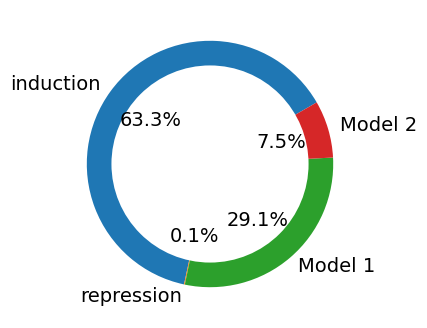

In [14]:
mv.pie_summary(adata_subset)

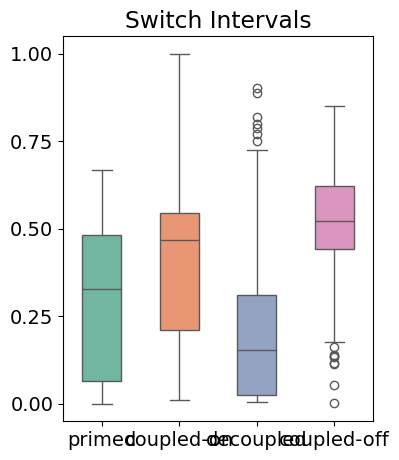

In [15]:
mv.switch_time_summary(adata_subset)

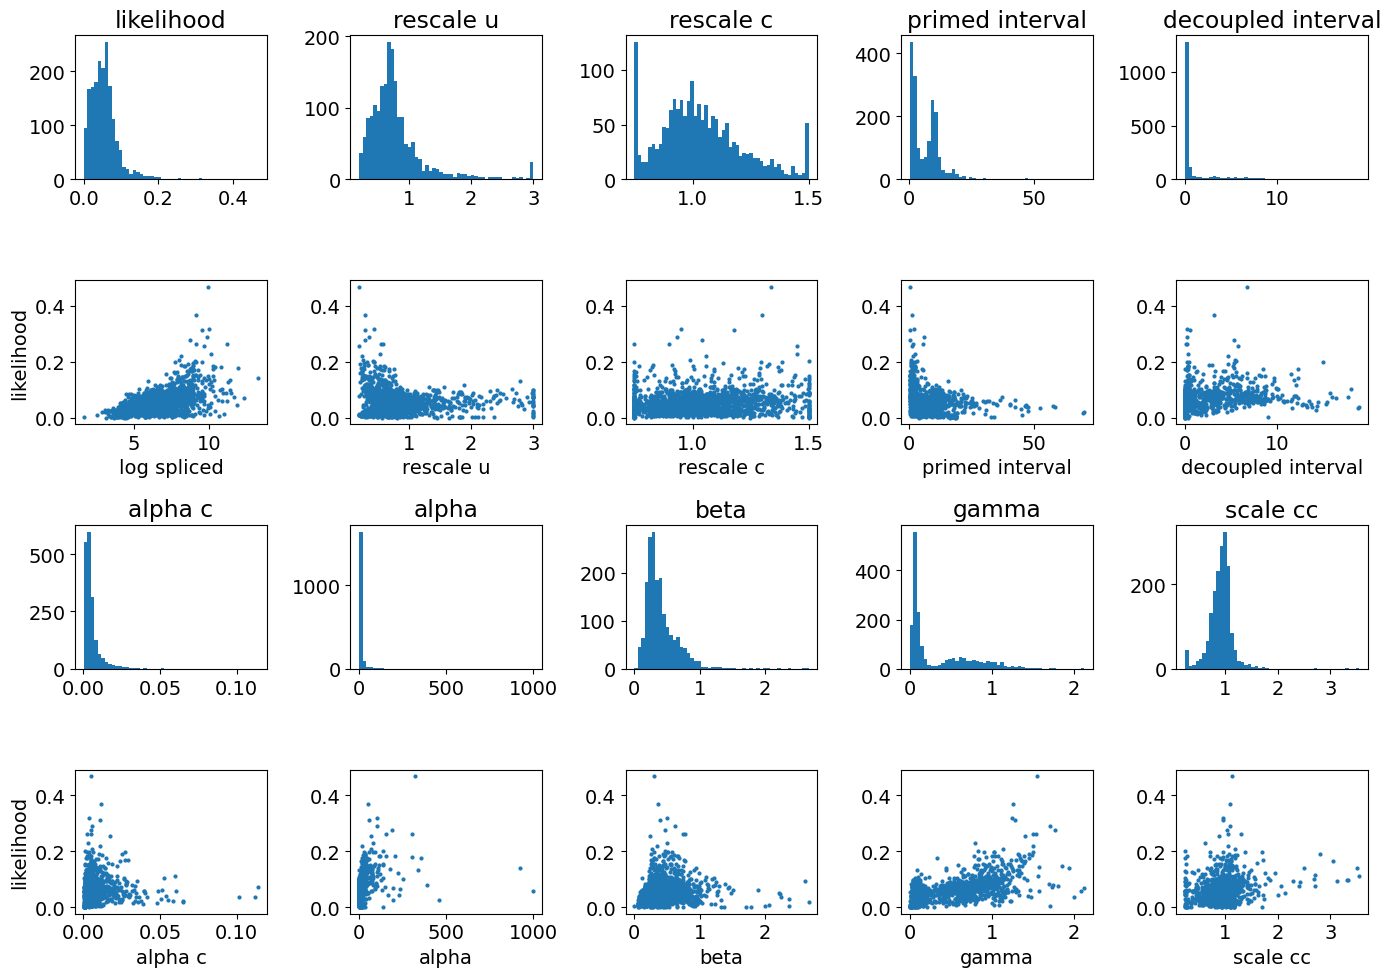

In [16]:
mv.likelihood_plot(adata_subset)

In [17]:
import scipy.sparse
scipy.sparse.coo_matrix.A = property(lambda self: self.toarray())
scipy.sparse.coo_array.A = property(lambda self: self.toarray())

In [18]:
import scvelo as scv

# recompute neighbors on the subset using MultiVI embedding
scv.pp.neighbors(adata_subset, use_rep='X_MultiVI', n_neighbors=30)

# now run velocity graph
mv.velocity_graph(adata_subset)
mv.latent_time(adata_subset)

computing neighbors
    finished (0:00:34) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 1/128 cores)


  0%|          | 0/14798 [00:00<?, ?cells/s]

    finished (0:00:36) --> added 
    'velo_s_norm_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 1 region of root cells and 1 region of end points .
    finished (0:00:01) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:00:26) --> added 
    'latent_time', shared time (adata.obs)


In [19]:
adata_subset

AnnData object with n_obs × n_vars = 14798 × 1841
    obs: 'celltype', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'S0_pseudotime', 'branch_id_alias', 'velo_s_norm_self_transition', 'root_cells', 'end_points', 'velo_s_norm_pseudotime', 'latent_time'
    var: 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_alpha_c', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_sw1', 'fit_t_sw2', 'fit_t_sw3', 'fit_scale_cc', 'fit_rescale_c', 'fit_rescale_u', 'fit_alignment_scaling', 'fit_model', 'fit_direction', 'fit_loss', 'fit_likelihood', 'fit_likelihood_c', 'fit_ssd_c', 'fit_var_c', 'fit_c0', 'fit_u0', 'fit_s0', 'fit_anchor_min_idx', 'fit_anchor_max_idx', 'fit_anchor_velo_min_idx', 'fit_anchor_velo_max_idx', 'velo_s_genes', 'velo_u_genes', 'velo_chrom_genes', 'velo_s_norm_genes'
    uns: 'celltype_colors', 'neighbors', 'velo_chrom_params', 'velo_s_params', 'velo_u_params', 'velo_s_norm_params', 'velo_s_norm_graph', 'velo_s_norm_

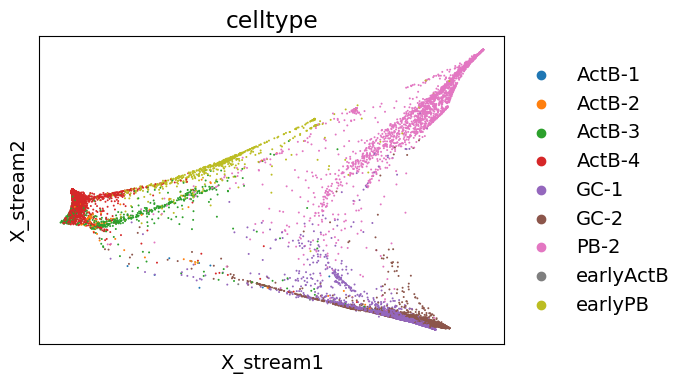

In [20]:
sc.pl.embedding(adata_subset, basis='X_stream', color='celltype')

computing velocity embedding
    finished (0:00:04) --> added
    'velo_s_norm_stream', embedded velocity vectors (adata.obsm)


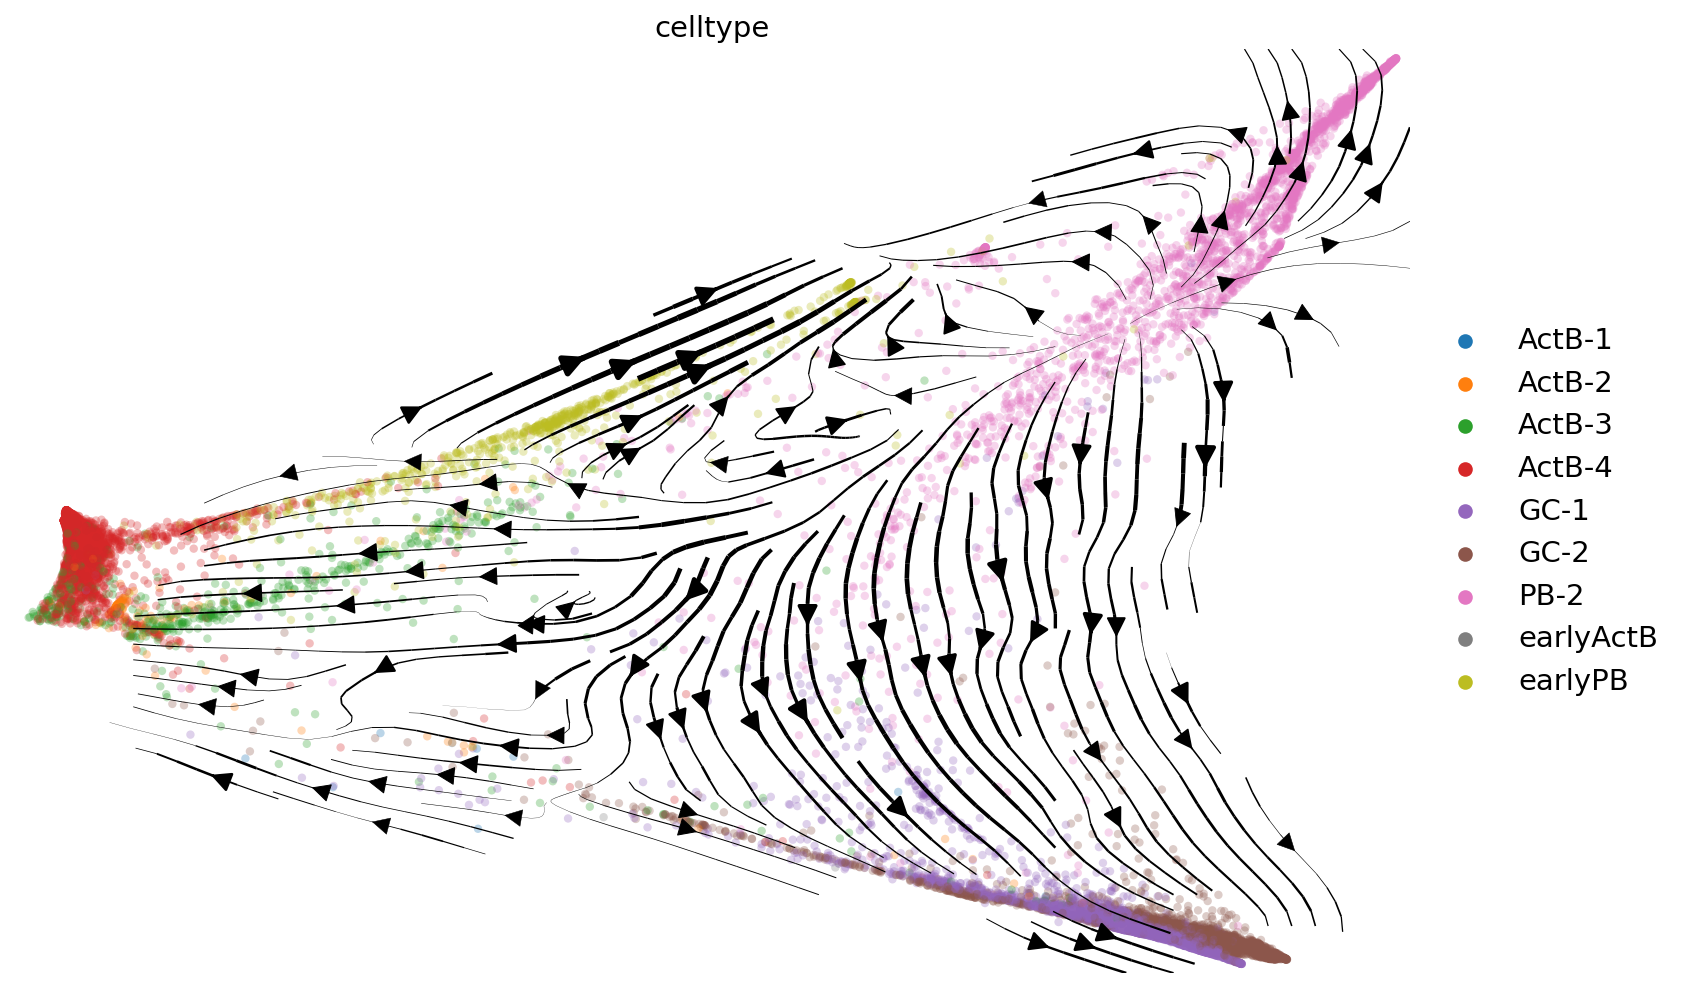

In [21]:
mv.velocity_embedding_stream(adata_subset, basis='stream', color='celltype',
    density=2,            # grid density (default 1, higher = more arrows)
    smooth=0.8,           # smoothing of velocity field (default 0.5)
    min_mass=2,           # minimum arrow mass threshold (lower = more arrows shown)
    arrow_size=2,         # scale arrow heads
    linewidth=1.5,        # thickness of streamlines
    legend_loc='right margin',
    figsize=(12, 8),
    dpi=150,)

In [23]:
# save adata_subset as h5ad
outs_dir = config.VELOCITY_IN_BASE
adata_subset.write_h5ad(os.path.join(outs_dir, "pb_gc_with_multivelo.h5ad"))